In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import numpy as np


X, y = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)


class SimpleNet(nn.Module):
    def __init__(self, activation_fn=nn.ReLU, input_size=2, hidden_size=64, output_size=1):
        print(self.parameters())
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        print(self.linear1.weight)
        self.activation1 = activation_fn()
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.activation2 = activation_fn()
        self.linear3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation1(x)
        x = self.linear2(x)
        x = self.activation2(x)
        x = self.linear3(x)
        return x






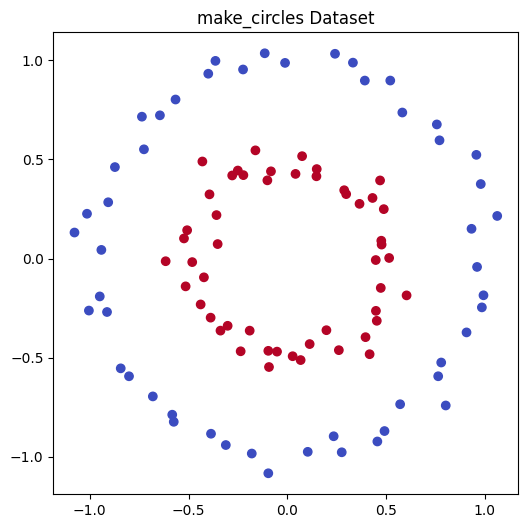

In [34]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap='coolwarm')
plt.title("make_circles Dataset")
plt.show()

In [35]:

# Training function
def train_model(model, X_data, y_data, epochs=10000, lr=0.001):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    lossi = []

    for i in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_data)
        loss = criterion(outputs, y_data)
        loss.backward()
        optimizer.step()
        lossi.append(loss.item())
    return lossi


Running Zero Initialization Experiments...
<generator object Module.parameters at 0x12d78eb20>
Parameter containing:
tensor([[ 0.0800, -0.5958],
        [-0.2705, -0.2078],
        [-0.3512,  0.4062],
        [ 0.0839, -0.3208],
        [ 0.2643,  0.3097],
        [ 0.4975,  0.2892],
        [ 0.0823,  0.5561],
        [ 0.2295,  0.5860],
        [ 0.6353, -0.3327],
        [-0.5115,  0.1275],
        [-0.4774,  0.4209],
        [ 0.5769,  0.3971],
        [-0.3850, -0.4868],
        [-0.4579,  0.6469],
        [-0.4324,  0.6049],
        [-0.0562, -0.5264],
        [-0.6421, -0.4708],
        [ 0.5524, -0.0338],
        [-0.6175, -0.5069],
        [-0.6455,  0.6743],
        [ 0.0171,  0.6163],
        [-0.1761, -0.2226],
        [ 0.3570, -0.5026],
        [ 0.2222,  0.5928],
        [-0.0721, -0.3830],
        [-0.4308,  0.4123],
        [-0.3361,  0.6597],
        [ 0.3335, -0.2123],
        [ 0.3398,  0.4044],
        [ 0.1345, -0.1640],
        [-0.3652,  0.6976],
        [ 0.164

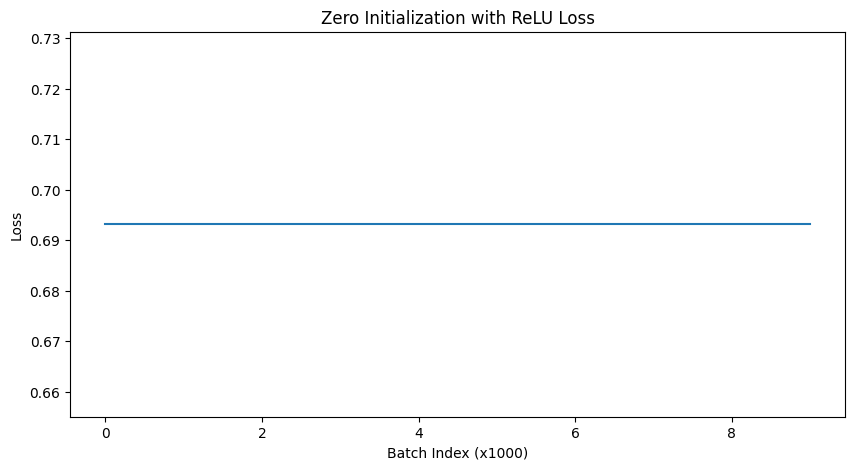

Parameter containing:
tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
      

In [37]:
print("Running Zero Initialization Experiments...")

# Zero Initialization with ReLU
model_zero_relu = SimpleNet(activation_fn=nn.ReLU)
for p in model_zero_relu.parameters():
    p.data.zero_()
lossi_zero_relu = train_model(model_zero_relu, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_zero_relu).view(-1, 1000).mean(1))
plt.title('Zero Initialization with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()

model_zero_relu.linear1.weight

<generator object Module.parameters at 0x12e0c0d60>
Parameter containing:
tensor([[ 0.4995, -0.1194],
        [ 0.2182,  0.1886],
        [ 0.0897, -0.2569],
        [ 0.4607, -0.3070],
        [ 0.4080, -0.1816],
        [ 0.4348, -0.6776],
        [ 0.3277,  0.2978],
        [-0.4430,  0.1002],
        [-0.1242, -0.7011],
        [ 0.4350, -0.5335],
        [-0.4827, -0.5803],
        [-0.5972,  0.5512],
        [-0.3754, -0.0963],
        [ 0.0795, -0.0207],
        [-0.6764, -0.4272],
        [-0.3868, -0.4986],
        [-0.3496, -0.0541],
        [-0.2526, -0.3665],
        [ 0.3526, -0.2166],
        [-0.6503, -0.6717],
        [-0.2313,  0.6850],
        [-0.5539, -0.6558],
        [-0.6070, -0.1965],
        [-0.0196,  0.2625],
        [-0.5943, -0.1019],
        [-0.1734,  0.4670],
        [-0.1886,  0.3886],
        [ 0.0563,  0.0430],
        [-0.0111, -0.0288],
        [-0.6915,  0.5795],
        [ 0.5265, -0.3575],
        [ 0.3908,  0.2696],
        [ 0.3488, -0.0177],
  

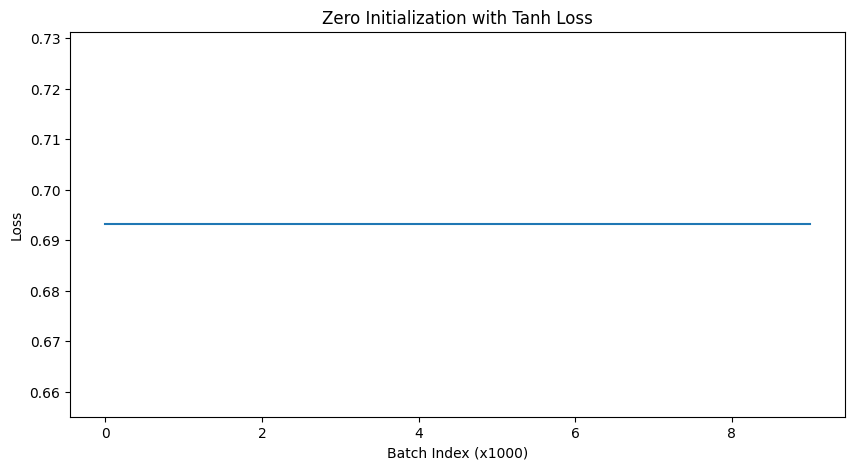

In [40]:
# Zero Initialization with Tanh
model_zero_tanh = SimpleNet(activation_fn=nn.Tanh)
for p in model_zero_tanh.parameters():
    p.data.zero_()
lossi_zero_tanh = train_model(model_zero_tanh, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_zero_tanh).view(-1, 1000).mean(1))
plt.title('Zero Initialization with Tanh Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()





<generator object Module.parameters at 0x12e0c34c0>
Parameter containing:
tensor([[-0.5922, -0.6134],
        [-0.5277, -0.5815],
        [-0.1182, -0.1610],
        [ 0.6243,  0.5886],
        [-0.3414,  0.3610],
        [ 0.3595, -0.4452],
        [ 0.4273,  0.0103],
        [ 0.3863, -0.6435],
        [ 0.3528,  0.6501],
        [-0.6482,  0.4722],
        [-0.3362, -0.1763],
        [-0.4876,  0.1681],
        [ 0.3411,  0.5145],
        [-0.5991,  0.3818],
        [ 0.0833, -0.5560],
        [ 0.1626,  0.2038],
        [-0.4089,  0.6595],
        [-0.3671,  0.6354],
        [-0.2432, -0.5432],
        [ 0.2721,  0.4056],
        [-0.6719, -0.4395],
        [-0.5446,  0.3619],
        [ 0.3483, -0.2906],
        [ 0.4972, -0.1782],
        [ 0.4104,  0.1272],
        [-0.4796, -0.1150],
        [-0.4032,  0.1076],
        [ 0.3150,  0.6825],
        [ 0.4777,  0.4576],
        [-0.3274, -0.6799],
        [-0.0857,  0.2250],
        [-0.4094, -0.6092],
        [-0.0674,  0.4153],
  

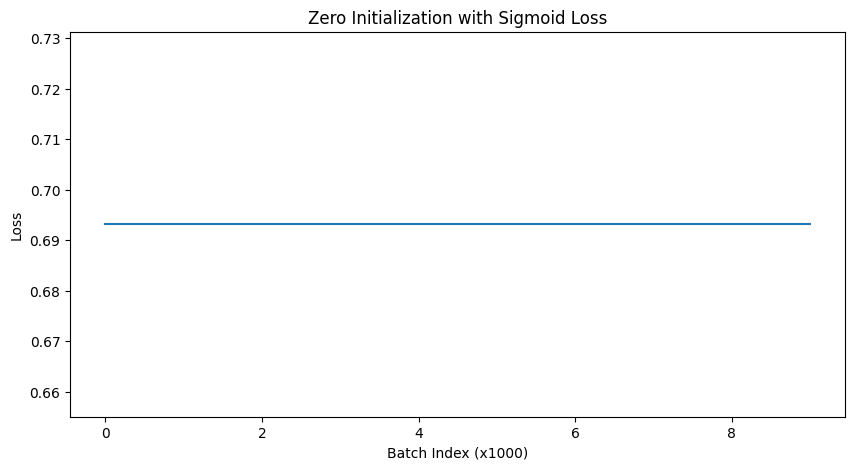

In [41]:
# Zero Initialization with Sigmoid
model_zero_sigmoid = SimpleNet(activation_fn=nn.Sigmoid)
for p in model_zero_sigmoid.parameters():
    p.data.zero_()
lossi_zero_sigmoid = train_model(model_zero_sigmoid, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_zero_sigmoid).view(-1, 1000).mean(1))
plt.title('Zero Initialization with Sigmoid Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()

Running Random Initialization Experiments...
<generator object Module.parameters at 0x12e13b220>
Parameter containing:
tensor([[-0.4726,  0.4896],
        [ 0.0056,  0.0954],
        [-0.2976, -0.1146],
        [ 0.5184, -0.0733],
        [ 0.6416,  0.4017],
        [-0.1075,  0.1900],
        [-0.3610,  0.6232],
        [ 0.4709, -0.2431],
        [ 0.2224, -0.2037],
        [ 0.0393,  0.3095],
        [ 0.0259, -0.6842],
        [ 0.4862,  0.2485],
        [-0.6609, -0.5540],
        [ 0.2020,  0.0238],
        [ 0.3921, -0.0892],
        [ 0.1653, -0.4735],
        [-0.6720,  0.6886],
        [ 0.1325, -0.0458],
        [ 0.0462, -0.4651],
        [ 0.3431,  0.0399],
        [ 0.4062,  0.4763],
        [-0.6620,  0.0546],
        [-0.0643,  0.4858],
        [-0.4278,  0.2155],
        [ 0.2957, -0.4902],
        [-0.4001,  0.6997],
        [ 0.6155, -0.1997],
        [-0.4258, -0.1553],
        [ 0.0714, -0.6949],
        [ 0.5107,  0.4460],
        [ 0.0118, -0.1615],
        [-0.5

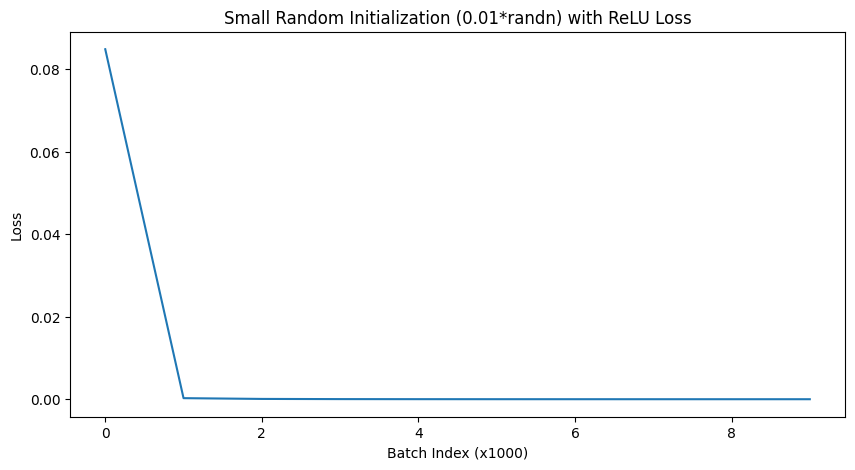

In [42]:
# Experiment 2: Random Initialization (with ReLU)
print("Running Random Initialization Experiments...")

# Small Random Initialization
model_small_rand = SimpleNet(activation_fn=nn.ReLU)
for p in model_small_rand.parameters():
    if p.dim() > 1:
        p.data.normal_(0, 0.01)
    else:
        p.data.zero_()
lossi_small_rand = train_model(model_small_rand, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_small_rand).view(-1, 1000).mean(1))
plt.title('Small Random Initialization (0.01*randn) with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()



<generator object Module.parameters at 0x11dde2ce0>
Parameter containing:
tensor([[-0.0719,  0.2677],
        [ 0.2111, -0.6341],
        [ 0.1287,  0.0950],
        [-0.1914, -0.0125],
        [-0.3852,  0.4236],
        [ 0.7004,  0.2001],
        [ 0.6068, -0.0299],
        [-0.5046,  0.5053],
        [-0.4324,  0.4100],
        [ 0.3632, -0.3337],
        [ 0.6140,  0.0465],
        [-0.4662,  0.6012],
        [ 0.0970, -0.3945],
        [ 0.2762, -0.0090],
        [ 0.2390, -0.1156],
        [ 0.1730, -0.1569],
        [-0.5749,  0.1757],
        [-0.3631, -0.4821],
        [ 0.5506,  0.2489],
        [ 0.0176,  0.2493],
        [-0.1847, -0.5382],
        [ 0.6950,  0.6626],
        [-0.1339,  0.3483],
        [ 0.6871,  0.5932],
        [ 0.6431, -0.4035],
        [-0.1302,  0.6233],
        [-0.5070,  0.2869],
        [-0.5760,  0.6195],
        [ 0.2487,  0.3684],
        [ 0.3021, -0.6922],
        [-0.3268, -0.3477],
        [-0.3413,  0.6884],
        [-0.3188, -0.1612],
  

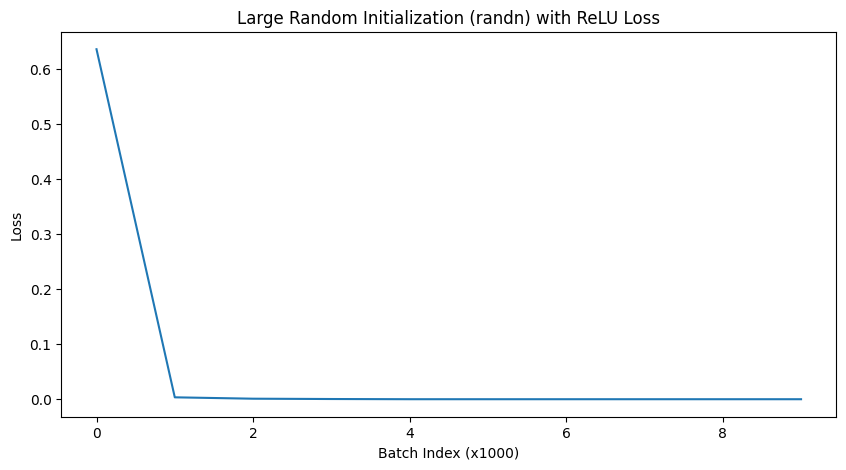

In [43]:
# Large Random Initialization
model_large_rand = SimpleNet(activation_fn=nn.ReLU)
for p in model_large_rand.parameters():
    if p.dim() > 1:
        p.data.normal_(0, 1)
    else:
        p.data.zero_()
lossi_large_rand = train_model(model_large_rand, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_large_rand).view(-1, 1000).mean(1))
plt.title('Large Random Initialization (randn) with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()




Running Xavier/Glorot Initialization Experiments...
<generator object Module.parameters at 0x12e0ed0e0>
Parameter containing:
tensor([[-4.1835e-01,  2.8964e-01],
        [ 4.4127e-01,  3.9944e-01],
        [ 4.2684e-01,  4.3166e-01],
        [ 4.2196e-01,  4.5208e-01],
        [-4.6969e-01,  4.4322e-01],
        [ 5.5425e-01,  1.6103e-01],
        [-3.4237e-01,  5.8105e-01],
        [ 1.0426e-01, -2.7709e-01],
        [-2.8033e-01,  1.0884e-01],
        [ 4.8034e-01, -3.7002e-01],
        [ 3.6319e-02, -1.4337e-01],
        [-1.9909e-01, -2.5096e-01],
        [-9.3401e-02,  5.0972e-01],
        [-5.4814e-01, -4.3663e-01],
        [ 8.5935e-02,  3.0850e-01],
        [-6.8768e-01,  5.8705e-01],
        [-9.6693e-02, -2.1477e-01],
        [-5.3571e-01,  4.6604e-01],
        [ 1.6949e-01,  6.4559e-01],
        [ 4.0697e-01, -6.8741e-01],
        [ 6.6098e-01,  4.7735e-01],
        [-1.7966e-01, -6.3667e-03],
        [-3.2624e-01, -1.9404e-01],
        [-2.4929e-01,  4.9115e-01],
        [ 

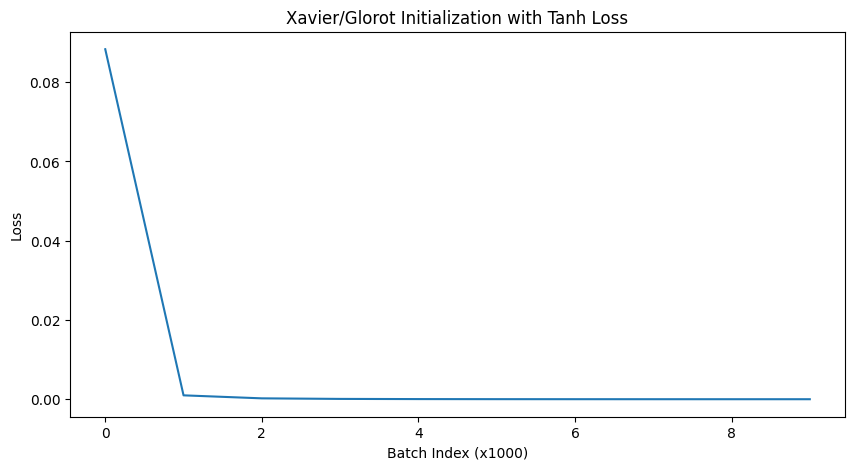

In [44]:
# Experiment 3: Xavier / Glorot Initialization (with Tanh/Sigmoid)
print("Running Xavier/Glorot Initialization Experiments...")

# Xavier/Glorot Initialization with Tanh
model_xavier_tanh = SimpleNet(activation_fn=nn.Tanh)
with torch.no_grad():
    for m in model_xavier_tanh.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            fan_out = m.weight.size(0)
            gain = 5/3  # For Tanh
            std = gain * (2 / (fan_in + fan_out))**0.5
            m.weight.normal_(0, std)
            if m.bias is not None:
                m.bias.zero_()
lossi_xavier_tanh = train_model(model_xavier_tanh, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_xavier_tanh).view(-1, 1000).mean(1))
plt.title('Xavier/Glorot Initialization with Tanh Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()




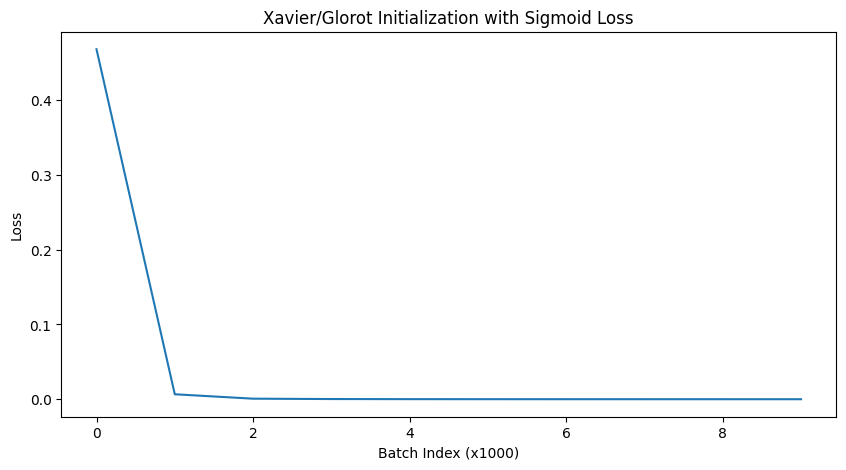

In [11]:

# Xavier/Glorot Initialization with Sigmoid
model_xavier_sigmoid = SimpleNet(activation_fn=nn.Sigmoid)
with torch.no_grad():
    for m in model_xavier_sigmoid.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            fan_out = m.weight.size(0)
            gain = 1.0  # For Sigmoid
            std = gain * (2 / (fan_in + fan_out))**0.5
            m.weight.normal_(0, std)
            if m.bias is not None:
                m.bias.zero_()
lossi_xavier_sigmoid = train_model(model_xavier_sigmoid, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_xavier_sigmoid).view(-1, 1000).mean(1))
plt.title('Xavier/Glorot Initialization with Sigmoid Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()

Running He Initialization Experiments...


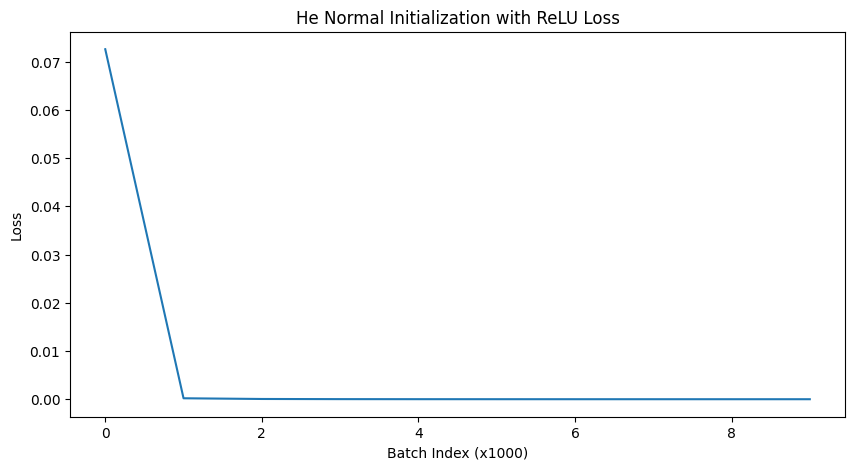

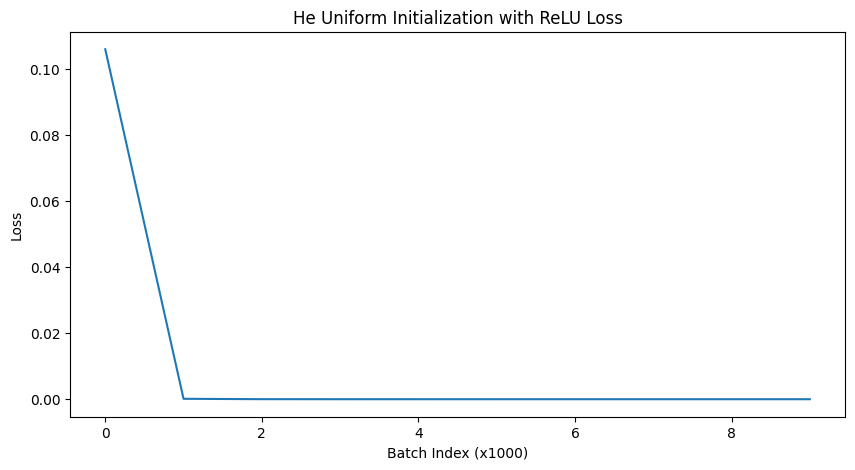

In [12]:




# Experiment 4: He Initialization (with ReLU)
print("Running He Initialization Experiments...")

# He Normal Initialization
model_he_normal = SimpleNet(activation_fn=nn.ReLU)
with torch.no_grad():
    for m in model_he_normal.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            gain = np.sqrt(2.0)  # For ReLU
            std = gain * (1 / fan_in)**0.5
            m.weight.normal_(0, std)
            if m.bias is not None:
                m.bias.zero_()
lossi_he_normal = train_model(model_he_normal, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_he_normal).view(-1, 1000).mean(1))
plt.title('He Normal Initialization with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()

# He Uniform Initialization
model_he_uniform = SimpleNet(activation_fn=nn.ReLU)
with torch.no_grad():
    for m in model_he_uniform.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            gain = np.sqrt(2.0)  # For ReLU
            bound = gain * (6 / fan_in)**0.5
            m.weight.uniform_(-bound, bound)
            if m.bias is not None:
                m.bias.zero_()
lossi_he_uniform = train_model(model_he_uniform, X, y)
plt.figure(figsize=(10, 5))
plt.plot(torch.tensor(lossi_he_uniform).view(-1, 1000).mean(1))
plt.title('He Uniform Initialization with ReLU Loss')
plt.xlabel('Batch Index (x1000)')
plt.ylabel('Loss')
plt.show()